<a href="https://colab.research.google.com/github/Mehtabul-Islam/CSE422---artificial-intelligence/blob/main/LAB%2002/Assignment_2_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSE422 Lab 02: Genetic Algorithm
Md. Mehtabul Islam | 24301400

# Assignment 2

## Problem Overview
In this problem, we aim to simulate a simplified version of VLSI floorplanning within a chip circuit. The objective is to determine the most optimal placement of 6 common chip components on a 2D chip grid. The goals are to minimize wire length, minimize the overall required chip area, and avoid overlapping chip components.

## Grid and Components
The chip grid is a $25 \times 25$ unit square. The chip contains the following 6 functional blocks with fixed sizes:
* **ALU**: Width 5, Height 5
* **Cache**: Width 7, Height 4
* **Control Unit**: Width 4, Height 4
* **Register File**: Width 6, Height 6
* **Decoder**: Width 5, Height 3
* **Floating Unit**: Width 5, Height 5

## Required Interconnections
The layout design must minimize the wiring distance between the following 6 connected component pairs:
1. Register File $\rightarrow$ ALU
2. Control Unit $\rightarrow$ ALU
3. ALU $\rightarrow$ Cache
4. Register File $\rightarrow$ Floating Unit
5. Cache $\rightarrow$ Decoder
6. Decoder $\rightarrow$ Floating Unit



## Fitness Objectives
1. **Minimizing total wiring distance:** Calculated using the Euclidean Distance between the centers of connected blocks.


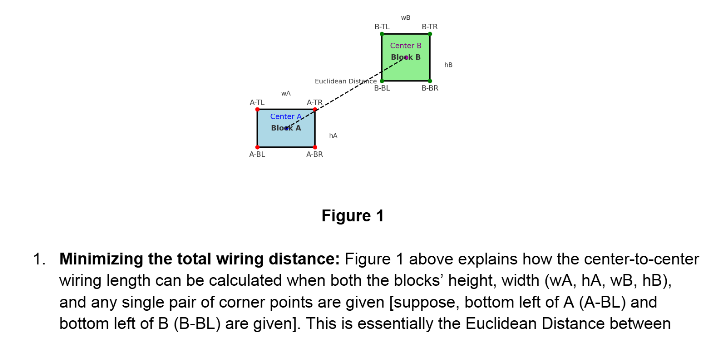
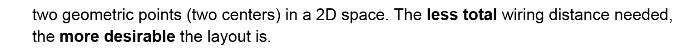

2. **Minimizing total bounding area:** Calculated using the smallest rectangle containing all blocks: $(x\_max - x\_min) \times (y\_max - y\_min)$.


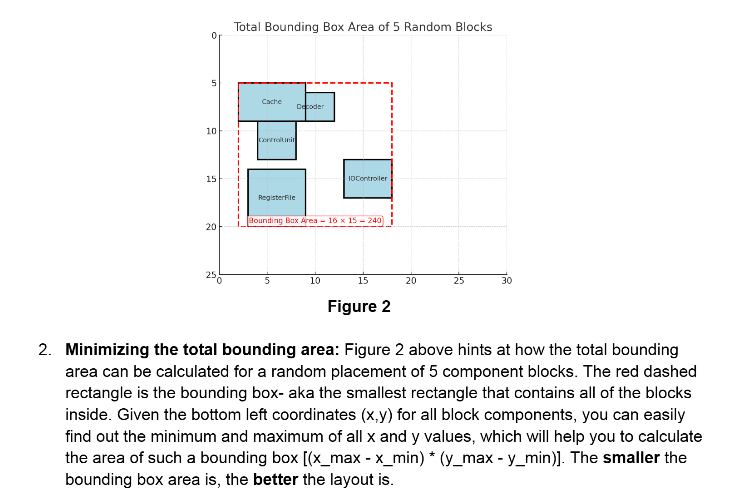

3. **Minimizing total component overlaps:** Checked using coordinate boundaries. Overlaps are highly penalized.

Where right, left, and top, bottom can be derived from the bottom-left x,y coordinate values of
both blocks and the width and height of the corresponding blocks, respectively. The idea is that
no overlap exists if one rectangle is completely to the left, right, above, or below the other.


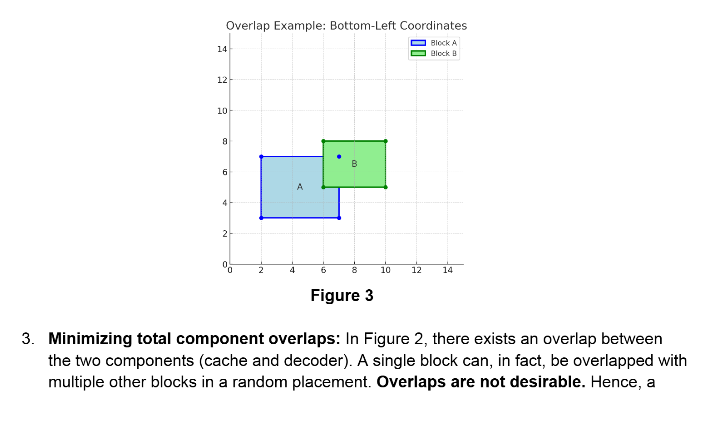
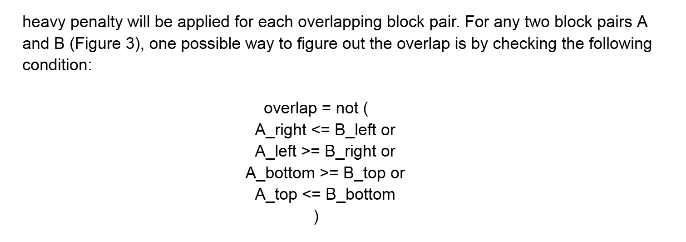



## Task 1 Instructions
Start with a random initial population of 6 members, where each chromosome represents a candidate layout. Suppose the layout is specified by all the bottom-left coordinates of the 6 components.

1. **Chromosome Representation / Encoding:** Devise a suitable encoding scheme to represent all the block components. Placement coordinate values will be in the range of $[0, 25]$. Generate an initial population of 6 chromosomes to start the GA loop.
2. **Fitness Function Implementation:** Based on the 3 fitness objectives outlined above, design a suitable fitness function that focuses on penalizing bad placement combinations. Overlap counts should be considered the least desirable, hence penalized way more than the other two. The total wiring distance and the total bounding area should be considered next.
3. **Parent Selection:** Choose two parents based on random selection at each generation.
4. **Cross-over:** Perform single-point crossover to create 2 new offspring from each pair of selected parents. Pick a random split point from the chromosome representation of the parents and swap the complementary pieces.
5. **Mutation:** Implement the following mutation strategy: pick any arbitrary component block from the chromosome representation and introduce random coordinate changes to that single particular block with a low probability (5-10% mutation rate).
6. **New Generation Creation:** Apply elitism to select new individuals (allow 1 or 2 elites to be carried forward to the next generation). Select the remaining candidates from the created offspring.
7. **GA Loop:** Run genetic algorithms on such a population until the best fitness is achieved or the maximum number of 15 iterations is reached.
8. **Required Output:** Output the best possible placement strategy found once the algorithm halts. Deliverables include the best total fitness value, the corresponding total wiring length, the total bounding box area, and the total overlap counts. Also, decode the best chromosome representation to reflect the optimal placement of bottom-left coordinates.

In [1]:
import math
import random

# Component definitions: (Width, Height)
COMPONENTS = {
    "ALU": (5, 5),
    "Cache": (7, 4),
    "Control Unit": (4, 4),
    "Register File": (6, 6),
    "Decoder": (5, 3),
    "Floating Unit": (5, 5)
}

# Ordered list of components to match chromosome indexing
COMP_NAMES = list(COMPONENTS.keys())

# Required wire connections (Index-based based on COMP_NAMES)
# 0: ALU, 1: Cache, 2: Control Unit, 3: Register File, 4: Decoder, 5: Floating Unit
CONNECTIONS = [
    (3, 0), # Register File -> ALU
    (2, 0), # Control Unit -> ALU
    (0, 1), # ALU -> Cache
    (3, 5), # Register File -> Floating Unit
    (1, 4), # Cache -> Decoder
    (4, 5)  # Decoder -> Floating Unit
]

# Grid limit
GRID_SIZE = 25

def get_center(x, y, w, h):
    return (x + w / 2, y + h / 2)

def calculate_fitness(chromosome, alpha=1000, beta=2, gamma=1):
    """
    Calculates fitness based on overlaps, wiring distance, and bounding area.
    """
    overlaps = 0
    wiring_distance = 0.0

    x_min_bound = float('inf')
    y_min_bound = float('inf')
    x_max_bound = float('-inf')
    y_max_bound = float('-inf')

    # 1. Calculate Overlaps & Bounding Box
    for i in range(len(chromosome)):
        x1, y1 = chromosome[i]
        w1, h1 = COMPONENTS[COMP_NAMES[i]]

        # Bounding box updates
        x_min_bound = min(x_min_bound, x1)
        y_min_bound = min(y_min_bound, y1)
        x_max_bound = max(x_max_bound, x1 + w1)
        y_max_bound = max(y_max_bound, y1 + h1)

        for j in range(i + 1, len(chromosome)):
            x2, y2 = chromosome[j]
            w2, h2 = COMPONENTS[COMP_NAMES[j]]

            # Overlap check logic
            overlap = not (
                (x1 + w1) <= x2 or  # A_right <= B_left
                x1 >= (x2 + w2) or  # A_left >= B_right
                y1 >= (y2 + h2) or  # A_bottom >= B_top
                (y1 + h1) <= y2     # A_top <= B_bottom
            )
            if overlap:
                overlaps += 1

    # 2. Calculate Wiring Distance
    for c1, c2 in CONNECTIONS:
        x1, y1 = chromosome[c1]
        w1, h1 = COMPONENTS[COMP_NAMES[c1]]
        cx1, cy1 = get_center(x1, y1, w1, h1)

        x2, y2 = chromosome[c2]
        w2, h2 = COMPONENTS[COMP_NAMES[c2]]
        cx2, cy2 = get_center(x2, y2, w2, h2)

        # Euclidean distance
        dist = math.sqrt((cx1 - cx2)**2 + (cy1 - cy2)**2)
        wiring_distance += dist

    # 3. Calculate Bounding Area
    bounding_area = (x_max_bound - x_min_bound) * (y_max_bound - y_min_bound)

    # Total Fitness Formula
    fitness_score = -(alpha * overlaps + beta * wiring_distance + gamma * bounding_area)

    return fitness_score, overlaps, wiring_distance, bounding_area

def generate_random_chromosome():
    """Generates a layout with random bottom-left coordinates within [0, 25]."""
    return [(random.randint(0, GRID_SIZE), random.randint(0, GRID_SIZE)) for _ in range(6)]

def single_point_crossover(p1, p2):
    """Performs single-point crossover."""
    split = random.randint(1, len(p1) - 1)
    c1 = p1[:split] + p2[split:]
    c2 = p2[:split] + p1[split:]
    return c1, c2

def mutate(chromosome, mutation_rate=0.1):
    """Mutates a chromosome by randomly changing one block's coordinates."""
    if random.random() < mutation_rate:
        idx = random.randint(0, len(chromosome) - 1)
        chromosome[idx] = (random.randint(0, GRID_SIZE), random.randint(0, GRID_SIZE))
    return chromosome

def run_ga_task1():
    population_size = 6
    generations = 15
    mutation_rate = 0.1

    # Start with a random initial population of 6 members
    population = [generate_random_chromosome() for _ in range(population_size)]

    best_chromosome = None
    best_fitness = float('-inf')
    best_stats = None

    # GA Loop for max 15 iterations
    for gen in range(generations):
        # Calculate fitness
        evaluated = []
        for chrom in population:
            fit, ov, wd, ba = calculate_fitness(chrom)
            evaluated.append({'chrom': chrom, 'fitness': fit, 'stats': (ov, wd, ba)})

            if fit > best_fitness:
                best_fitness = fit
                best_chromosome = chrom
                best_stats = (ov, wd, ba)

        # Sort by fitness (descending, since values are negative and closer to 0 is better)
        evaluated.sort(key=lambda x: x['fitness'], reverse=True)

        new_population = []

        # Elitism: carry forward the top 2 candidates
        new_population.append(evaluated[0]['chrom'])
        new_population.append(evaluated[1]['chrom'])

        # Generate offspring
        while len(new_population) < population_size:
            # Random selection for parents
            p1 = random.choice(evaluated)['chrom']
            p2 = random.choice(evaluated)['chrom']

            c1, c2 = single_point_crossover(p1, p2)

            new_population.append(mutate(c1, mutation_rate))
            if len(new_population) < population_size:
                new_population.append(mutate(c2, mutation_rate))

        population = new_population

    print("--- Task 1: Best Placement Found ---")
    print(f"Coordinates: {best_chromosome}")
    print(f"Total Fitness: {best_fitness:.2f}")
    print(f"Overlap Count: {best_stats[0]}")
    print(f"Wiring Distance: {best_stats[1]:.2f}")
    print(f"Bounding Area: {best_stats[2]:.2f}")
    print("\nDecoding Placement (Bottom-Left Coordinates):")
    for i, name in enumerate(COMP_NAMES):
        print(f"  {name}: {best_chromosome[i]}")

# Run Task 1
run_ga_task1()

--- Task 1: Best Placement Found ---
Coordinates: [(12, 9), (14, 15), (17, 2), (24, 2), (4, 4), (23, 11)]
Total Fitness: -590.52
Overlap Count: 0
Wiring Distance: 74.26
Bounding Area: 442.00

Decoding Placement (Bottom-Left Coordinates):
  ALU: (12, 9)
  Cache: (14, 15)
  Control Unit: (17, 2)
  Register File: (24, 2)
  Decoder: (4, 4)
  Floating Unit: (23, 11)


## Task 2 Instructions
Take a look at Step 4 of Task 1. Can you incorporate the Two-point crossover mechanism into it?

To implement this task, randomly select two parents from your initial population. Then perform a two-point crossover to generate two children. The two points have to be chosen randomly, but it has to be ensured that the second point always comes after the first point.

## Sample Input and Output

A sample initial population set of 6 chromosomes, where each line below represents the bottom-left position coordinate of 6 chip component blocks:

* **P1** -> (9,3), (12, 15), (13, 16), (1,13), (4,15), (9, 6)
* **P2** -> (8, 0), (7,12), (4,11), (1,13), (14,10), (9,11)
* **P3** -> (6, 5), (12, 9), (9, 7), (8, 6), (2, 7), (3, 1)
* **P4** -> (3,11), (11, 12), (14, 11), (6, 10), (3,11), (3,0)
* **P5** -> (10, 12), (8, 16), (10, 4), (13, 6), (6, 0), (3, 7)
* **P6** -> (0, 2), (0, 0), (14, 12), (4, 5), (12, 4), (3, 10)

**For P1:**
* **Pairwise block overlap count** = 3
* **Total wiring distance (center-to-center) of the specified connected pairs** = 12.91 + 12.98 + 12.18 + 10.61 + 9.01 + 9.43 = 67.1
* **Total bounding box area** = (x_max - x_min) * (y_max - y_min) = (19-1) * (20-3) = 306
* **Total fitness value** = - (alpha * overlap penalty + beta * wiring length penalty + gamma * bounding area penalty)

Considering, alpha = 1000, beta = 2, gamma = 1:
* **Fitness for generation 1 chromosome 1** = - (1000 * 3) - (67.1 * 2) - 306 = -3440.23

In [3]:
import math

# Component definitions: (Width, Height)
COMPONENTS = {
    "ALU": (5, 5),
    "Cache": (7, 4),
    "Control Unit": (4, 4),
    "Register File": (6, 6),
    "Decoder": (5, 3),
    "Floating Unit": (5, 5)
}

COMP_NAMES = list(COMPONENTS.keys())

# Required wire connections
CONNECTIONS = [
    (3, 0), # Register File -> ALU
    (2, 0), # Control Unit -> ALU
    (0, 1), # ALU -> Cache
    (3, 5), # Register File -> Floating Unit
    (1, 4), # Cache -> Decoder
    (4, 5)  # Decoder -> Floating Unit
]

def get_center(x, y, w, h):
    return (x + w / 2, y + h / 2)

def calculate_sample_fitness(chromosome, alpha=1000, beta=2, gamma=1):
    overlaps = 0
    wiring_distance = 0.0

    x_min_bound = float('inf')
    y_min_bound = float('inf')
    x_max_bound = float('-inf')
    y_max_bound = float('-inf')

    # 1. Calculate Overlaps & Bounding Box
    for i in range(len(chromosome)):
        x1, y1 = chromosome[i]
        w1, h1 = COMPONENTS[COMP_NAMES[i]]

        x_min_bound = min(x_min_bound, x1)
        y_min_bound = min(y_min_bound, y1)
        x_max_bound = max(x_max_bound, x1 + w1)
        y_max_bound = max(y_max_bound, y1 + h1)

        for j in range(i + 1, len(chromosome)):
            x2, y2 = chromosome[j]
            w2, h2 = COMPONENTS[COMP_NAMES[j]]

            overlap = not (
                (x1 + w1) <= x2 or
                x1 >= (x2 + w2) or
                y1 >= (y2 + h2) or
                (y1 + h1) <= y2
            )
            if overlap:
                overlaps += 1

    # 2. Calculate Wiring Distance
    for c1, c2 in CONNECTIONS:
        x1, y1 = chromosome[c1]
        w1, h1 = COMPONENTS[COMP_NAMES[c1]]
        cx1, cy1 = get_center(x1, y1, w1, h1)

        x2, y2 = chromosome[c2]
        w2, h2 = COMPONENTS[COMP_NAMES[c2]]
        cx2, cy2 = get_center(x2, y2, w2, h2)

        dist = math.sqrt((cx1 - cx2)**2 + (cy1 - cy2)**2)
        wiring_distance += dist

    # 3. Calculate Bounding Area
    bounding_area = (x_max_bound - x_min_bound) * (y_max_bound - y_min_bound)

    # Total Fitness Score
    fitness_score = -(alpha * overlaps + beta * wiring_distance + gamma * bounding_area)

    return fitness_score, overlaps, wiring_distance, bounding_area


# ==========================================
# TEST WITH SAMPLE POPULATION INDIVIDUALLY
# ==========================================

# --- Testing P1 ---
P1 = [(9, 3), (12, 15), (13, 16), (1, 13), (4, 15), (9, 6)]
fitness1, overlaps1, wiring1, area1 = calculate_sample_fitness(P1)

print("--- Sample Calculation for P1 ---")
print(f"P1 Coordinates: {P1}")
print(f"Overlap Count: {overlaps1}")
print(f"Wiring Distance: {wiring1:.2f}")
print(f"Bounding Area: {area1}")
print(f"Total Fitness: {fitness1:.2f}\n")


# --- Testing P2 ---
P2 = [(8, 0), (7, 12), (4, 11), (1, 13), (14, 10), (9, 11)]
fitness2, overlaps2, wiring2, area2 = calculate_sample_fitness(P2)

print("--- Sample Calculation for P2 ---")
print(f"P2 Coordinates: {P2}")
print(f"Overlap Count: {overlaps2}")
print(f"Wiring Distance: {wiring2:.2f}")
print(f"Bounding Area: {area2}")
print(f"Total Fitness: {fitness2:.2f}\n")


# --- Testing P3 ---
P3 = [(6, 5), (12, 9), (9, 7), (8, 6), (2, 7), (3, 1)]
fitness3, overlaps3, wiring3, area3 = calculate_sample_fitness(P3)

print("--- Sample Calculation for P3 ---")
print(f"P3 Coordinates: {P3}")
print(f"Overlap Count: {overlaps3}")
print(f"Wiring Distance: {wiring3:.2f}")
print(f"Bounding Area: {area3}")
print(f"Total Fitness: {fitness3:.2f}\n")


# --- Testing P4 ---
P4 = [(3, 11), (11, 12), (14, 11), (6, 10), (3, 11), (3, 0)]
fitness4, overlaps4, wiring4, area4 = calculate_sample_fitness(P4)

print("--- Sample Calculation for P4 ---")
print(f"P4 Coordinates: {P4}")
print(f"Overlap Count: {overlaps4}")
print(f"Wiring Distance: {wiring4:.2f}")
print(f"Bounding Area: {area4}")
print(f"Total Fitness: {fitness4:.2f}\n")


# --- Testing P5 ---
P5 = [(10, 12), (8, 16), (10, 4), (13, 6), (6, 0), (3, 7)]
fitness5, overlaps5, wiring5, area5 = calculate_sample_fitness(P5)

print("--- Sample Calculation for P5 ---")
print(f"P5 Coordinates: {P5}")
print(f"Overlap Count: {overlaps5}")
print(f"Wiring Distance: {wiring5:.2f}")
print(f"Bounding Area: {area5}")
print(f"Total Fitness: {fitness5:.2f}\n")


# --- Testing P6 ---
P6 = [(0, 2), (0, 0), (14, 12), (4, 5), (12, 4), (3, 10)]
fitness6, overlaps6, wiring6, area6 = calculate_sample_fitness(P6)

print("--- Sample Calculation for P6 ---")
print(f"P6 Coordinates: {P6}")
print(f"Overlap Count: {overlaps6}")
print(f"Wiring Distance: {wiring6:.2f}")
print(f"Bounding Area: {area6}")
print(f"Total Fitness: {fitness6:.2f}\n")

--- Sample Calculation for P1 ---
P1 Coordinates: [(9, 3), (12, 15), (13, 16), (1, 13), (4, 15), (9, 6)]
Overlap Count: 3
Wiring Distance: 67.11
Bounding Area: 306
Total Fitness: -3440.23

--- Sample Calculation for P2 ---
P2 Coordinates: [(8, 0), (7, 12), (4, 11), (1, 13), (14, 10), (9, 11)]
Overlap Count: 3
Wiring Distance: 57.70
Bounding Area: 342
Total Fitness: -3457.40

--- Sample Calculation for P3 ---
P3 Coordinates: [(6, 5), (12, 9), (9, 7), (8, 6), (2, 7), (3, 1)]
Overlap Count: 7
Wiring Distance: 37.81
Bounding Area: 204
Total Fitness: -7279.63

--- Sample Calculation for P4 ---
P4 Coordinates: [(3, 11), (11, 12), (14, 11), (6, 10), (3, 11), (3, 0)]
Overlap Count: 5
Wiring Distance: 53.25
Bounding Area: 240
Total Fitness: -5346.51

--- Sample Calculation for P5 ---
P5 Coordinates: [(10, 12), (8, 16), (10, 4), (13, 6), (6, 0), (3, 7)]
Overlap Count: 2
Wiring Distance: 54.50
Bounding Area: 320
Total Fitness: -2429.00

--- Sample Calculation for P6 ---
P6 Coordinates: [(0, 2), (